In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print("=== Базовая информация о датасете ===")
df.info()

print("\n=== Количество пропущенных значений по признакам ===")
missing_values = df.isnull().sum()
print(missing_values)

print("\n=== Характеристика числовых данных ===")
display(df.describe())

=== Базовая информация о датасете ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales         

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


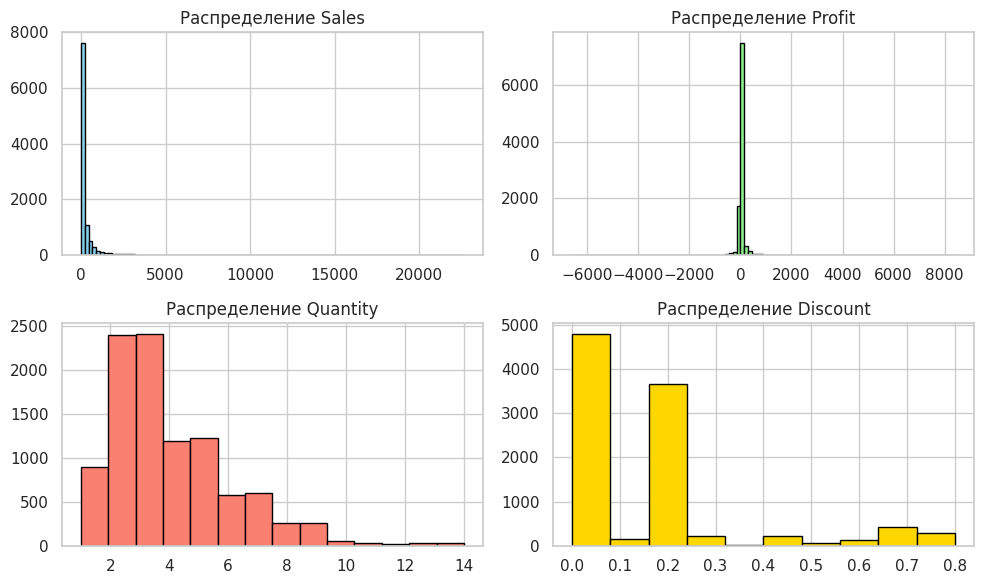

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0, 0].hist(df['Sales'], bins=100, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Распределение Sales')

axes[0, 1].hist(df['Profit'], bins=100, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Распределение Profit')

axes[1, 0].hist(df['Quantity'], bins=14, color='salmon', edgecolor='black')
axes[1, 0].set_title('Распределение Quantity')

axes[1, 1].hist(df['Discount'], bins=10, color='gold', edgecolor='black')
axes[1, 1].set_title('Распределение Discount')

plt.tight_layout()
plt.show()




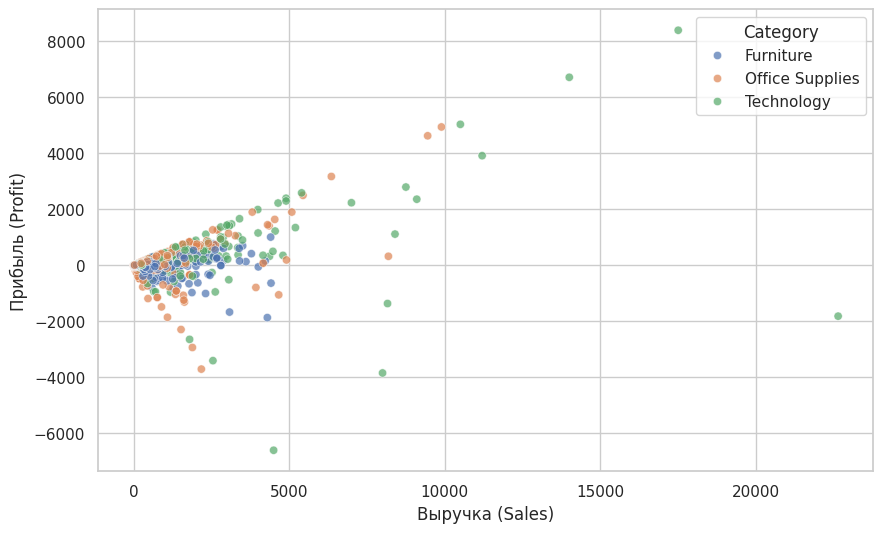

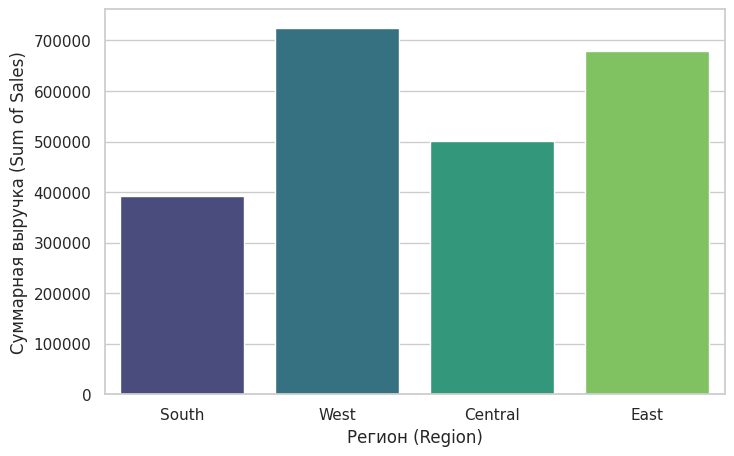

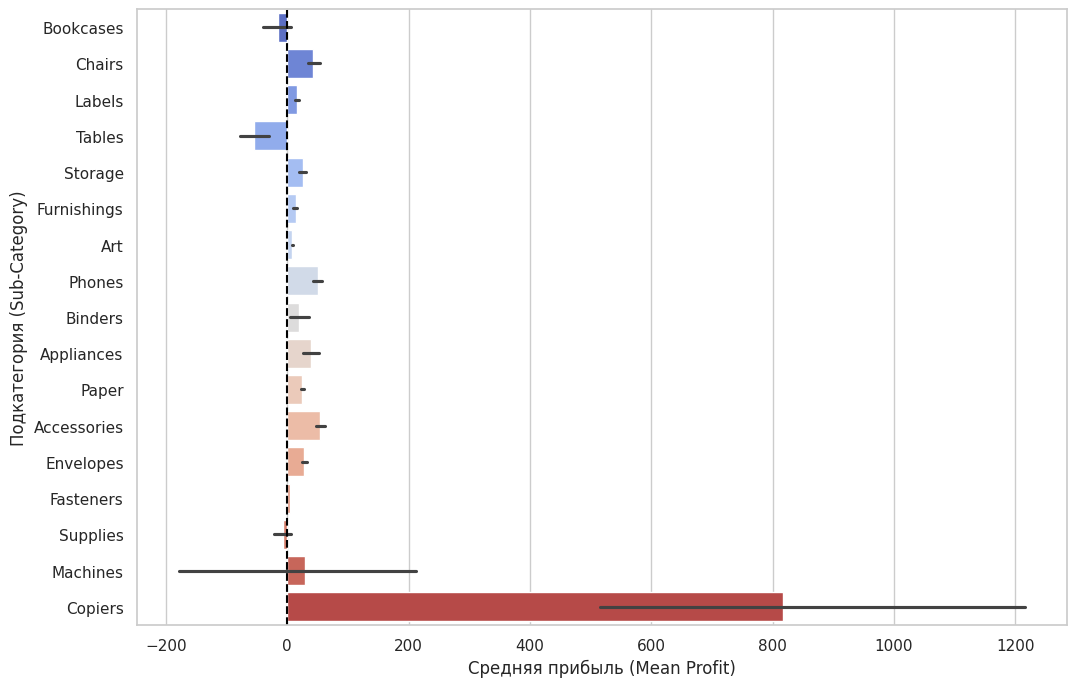

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha=0.7)
plt.xlabel('Выручка (Sales)')
plt.ylabel('Прибыль (Profit)')
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Region', y='Sales', estimator=sum, errorbar=None, hue='Region', palette='viridis', legend=False)
plt.xlabel('Регион (Region)')
plt.ylabel('Суммарная выручка (Sum of Sales)')
plt.show()


plt.figure(figsize=(12, 8))
sns.barplot(data=df, x='Profit', y='Sub-Category', hue='Sub-Category', palette='coolwarm', legend=False)
plt.xlabel('Средняя прибыль (Mean Profit)')
plt.ylabel('Подкатегория (Sub-Category)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

fig1 = px.histogram(df, x="Sales",
                   nbins=100,
                   marginal="box",
                   color_discrete_sequence=['indianred'])
fig1.update_layout(bargap=0.1)
fig1.show()
print()

fig2 = px.scatter(df, x="Sales", y="Profit",
                  color="Category",
                  hover_data=['Sub-Category', 'Customer Name'])

fig2.add_hline(y=0, line_dash="dot", line_color="black")
fig2.show()

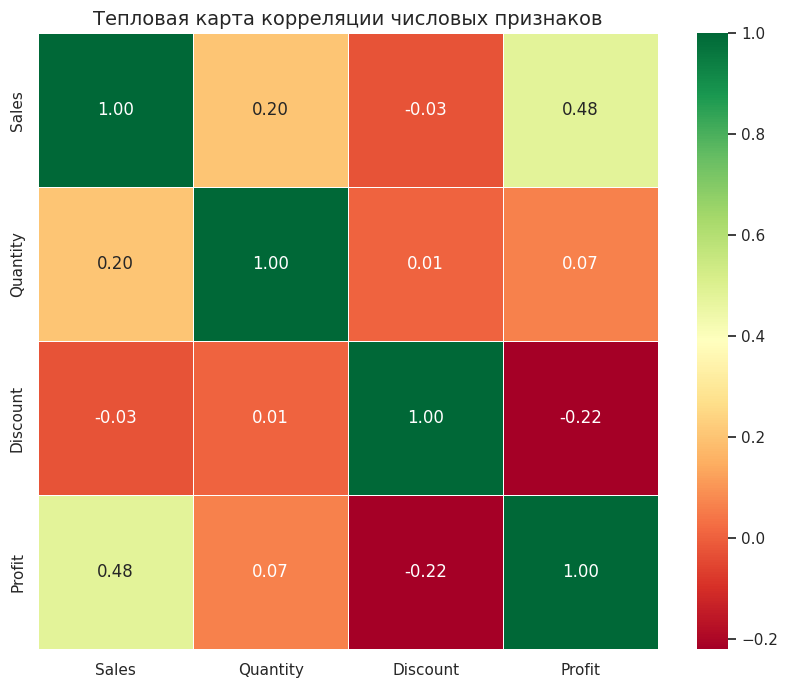

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')


plt.figure(figsize=(10, 8))
numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляции числовых признаков', fontsize=14)
plt.show()



In [8]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print("=== 1. Фильтрация по одному признаку (Убыточные сделки) ===")
loss_making = df[df['Profit'] < 0]
print(f"Количество строк: {loss_making.shape[0]}")
print(loss_making[['Sales', 'Discount', 'Profit']].describe())
print("\n" + "="*50 + "\n")

print("=== 2. Фильтрация по двум признакам (Техника, без скидки) ===")
tech_high_vol = df[(df['Category'] == 'Technology') &
                   (df['Discount'] == 0)]
print(f"Количество строк: {tech_high_vol.shape[0]}")
print(tech_high_vol[['Sales', 'Quantity', 'Profit']].describe())
print("\n" + "="*50 + "\n")

print("=== 3. Фильтрация по трем признакам (Убыточная мебель на Юге) ===")
problem_furniture = df[(df['Category'] == 'Furniture') &
                       (df['Region'] == 'South') &
                       (df['Profit'] < 0)]
print(f"Количество строк: {problem_furniture.shape[0]}")
print(problem_furniture[['Sales', 'Discount', 'Profit']].describe())

=== 1. Фильтрация по одному признаку (Убыточные сделки) ===
Количество строк: 1871
              Sales     Discount       Profit
count   1871.000000  1871.000000  1871.000000
mean     250.511574     0.480887   -83.448042
std      715.067296     0.235080   284.423422
min        0.444000     0.100000 -6599.978000
25%       12.503000     0.200000   -58.660950
50%       71.088000     0.400000   -18.088200
75%      284.922000     0.700000    -6.261500
max    22638.480000     0.800000    -0.089500


=== 2. Фильтрация по двум признакам (Техника, без скидки) ===
Количество строк: 833
              Sales    Quantity       Profit
count    833.000000  833.000000   833.000000
mean     467.866987    3.789916   158.881657
std     1166.289812    2.302861   502.632394
min        0.990000    1.000000     0.000000
25%       71.980000    2.000000    15.220800
50%      159.980000    3.000000    43.598100
75%      437.850000    5.000000   129.348000
max    17499.950000   14.000000  8399.976000


=== 3. Фил

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

df_noisy = df.copy()

print("=== Статистика ДО добавления шума ===")
print(df_noisy[['Discount', 'Quantity']].describe().T[['mean', 'std', 'min', 'max']])
print("\n" + "="*50 + "\n")

noise_discount = np.random.normal(0, 0.02, size=len(df_noisy))
df_noisy['Discount_noisy'] = df_noisy['Discount'] + noise_discount

df_noisy['Discount_noisy'] = df_noisy['Discount_noisy'].clip(lower=0.0, upper=0.8)


noise_quantity = np.random.randint(-1, 2, size=len(df_noisy))
df_noisy['Quantity_noisy'] = df_noisy['Quantity'] + noise_quantity

df_noisy['Quantity_noisy'] = df_noisy['Quantity_noisy'].clip(lower=1)


print("=== Статистика ПОСЛЕ добавления шума ===")
print(df_noisy[['Discount_noisy', 'Quantity_noisy']].describe().T[['mean', 'std', 'min', 'max']])

=== Статистика ДО добавления шума ===
              mean       std  min   max
Discount  0.156203  0.206452  0.0   0.8
Quantity  3.789574  2.225110  1.0  14.0


=== Статистика ПОСЛЕ добавления шума ===
                    mean       std  min   max
Discount_noisy  0.159729  0.203317  0.0   0.8
Quantity_noisy  3.815890  2.331465  1.0  15.0


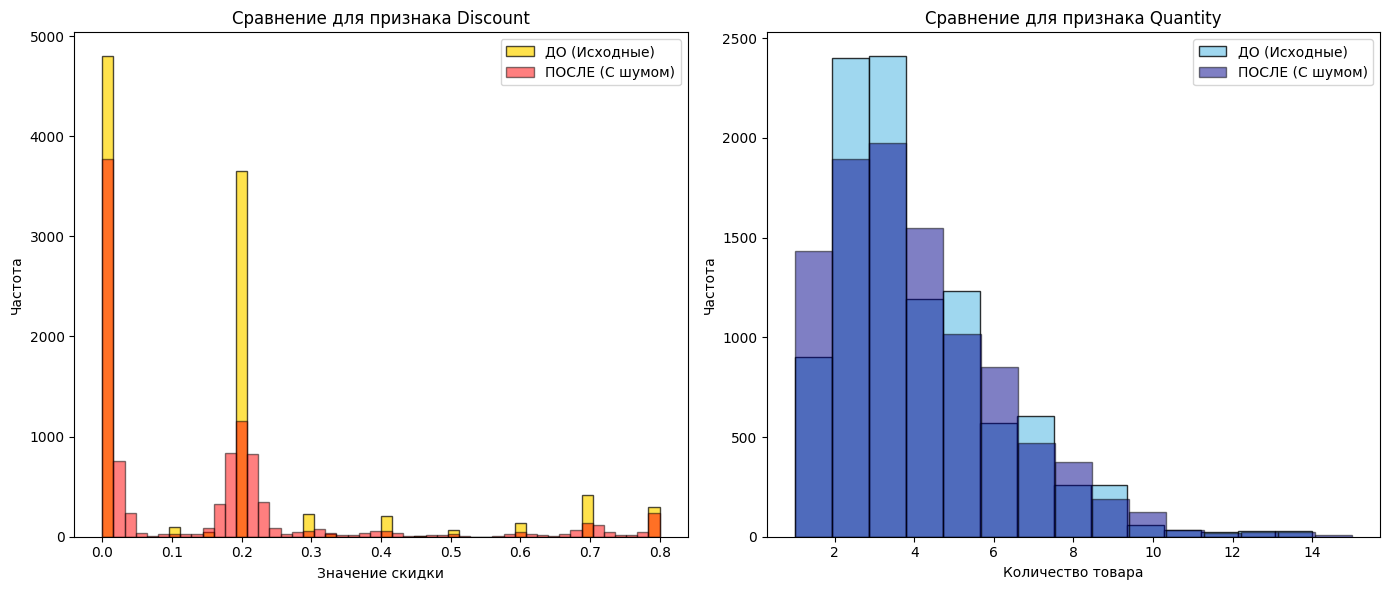

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

df_transformed = df.copy()

noise_discount = np.random.normal(0, 0.02, size=len(df_transformed))
df_transformed['Discount_noisy'] = (df_transformed['Discount'] + noise_discount).clip(lower=0.0, upper=0.8)

noise_quantity = np.random.randint(-1, 2, size=len(df_transformed))
df_transformed['Quantity_noisy'] = (df_transformed['Quantity'] + noise_quantity).clip(lower=1)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df['Discount'], bins=50, color='gold', edgecolor='black', alpha=0.7, label='ДО (Исходные)')
axes[0].hist(df_transformed['Discount_noisy'], bins=50, color='red', edgecolor='black', alpha=0.5, label='ПОСЛЕ (С шумом)')
axes[0].set_title('Сравнение для признака Discount')
axes[0].set_xlabel('Значение скидки')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(df['Quantity'], bins=14, color='skyblue', edgecolor='black', alpha=0.8, label='ДО (Исходные)')
axes[1].hist(df_transformed['Quantity_noisy'], bins=15, color='darkblue', edgecolor='black', alpha=0.5, label='ПОСЛЕ (С шумом)')
axes[1].set_title('Сравнение для признака Quantity')
axes[1].set_xlabel('Количество товара')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

cat_features = ['Ship Mode', 'Segment', 'Region', 'Category']

print("=== Список всех категорий по признакам ===\n")

for feature in cat_features:
    unique_cats = sorted(df[feature].unique().astype(str))

    print(f"{feature}:")
    print(f"Количество: {len(unique_cats)}")
    print(f"Значения: {', '.join(unique_cats)}")
    print("-" * 30)



=== Список всех категорий по признакам ===

Ship Mode:
Количество: 4
Значения: First Class, Same Day, Second Class, Standard Class
------------------------------
Segment:
Количество: 3
Значения: Consumer, Corporate, Home Office
------------------------------
Region:
Количество: 4
Значения: Central, East, South, West
------------------------------
Category:
Количество: 3
Значения: Furniture, Office Supplies, Technology
------------------------------


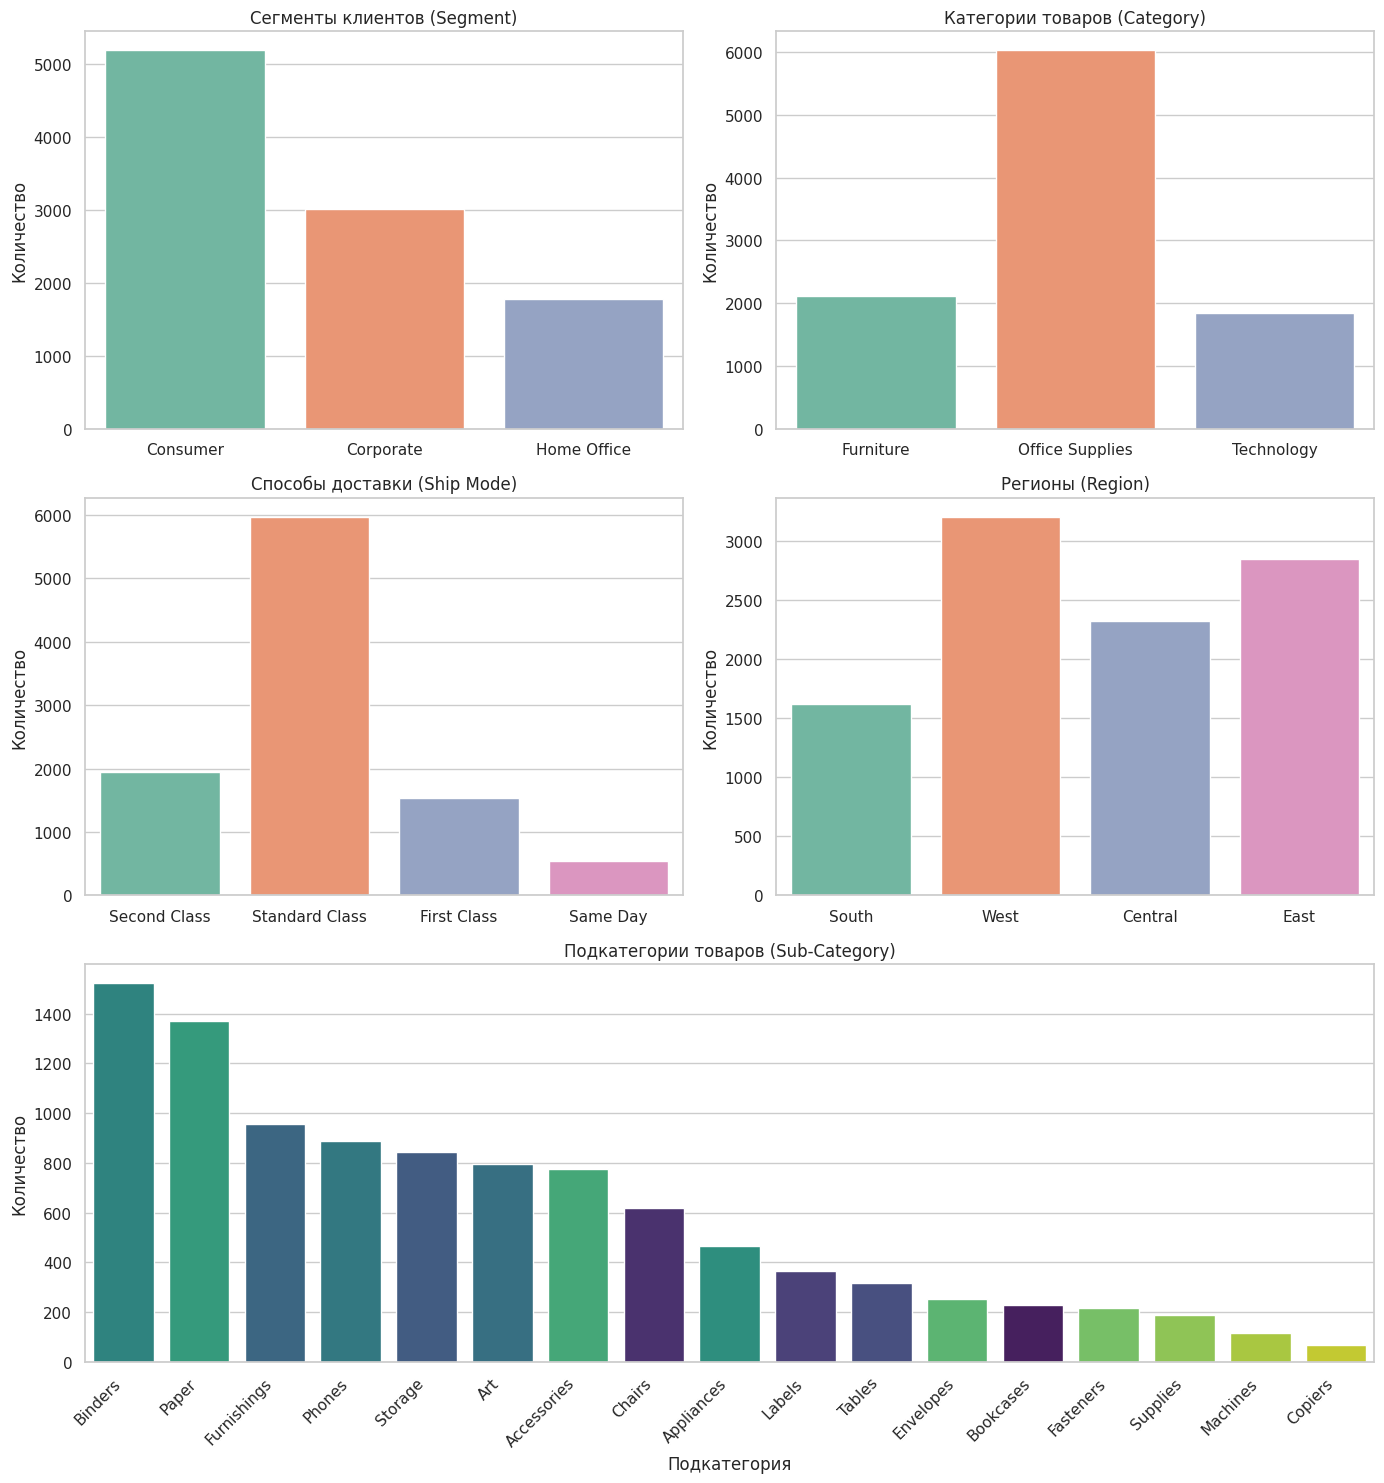

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(14, 15))

ax1 = plt.subplot(3, 2, 1)
sns.countplot(data=df, x='Segment', palette='Set2', hue='Segment', legend=False, ax=ax1)
ax1.set_title('Сегменты клиентов (Segment)')
ax1.set_ylabel('Количество')
ax1.set_xlabel('')

ax2 = plt.subplot(3, 2, 2)
sns.countplot(data=df, x='Category', palette='Set2', hue='Category', legend=False, ax=ax2)
ax2.set_title('Категории товаров (Category)')
ax2.set_ylabel('Количество')
ax2.set_xlabel('')

ax3 = plt.subplot(3, 2, 3)
sns.countplot(data=df, x='Ship Mode', palette='Set2', hue='Ship Mode', legend=False, ax=ax3)
ax3.set_title('Способы доставки (Ship Mode)')
ax3.set_ylabel('Количество')
ax3.set_xlabel('')

ax4 = plt.subplot(3, 2, 4)
sns.countplot(data=df, x='Region', palette='Set2', hue='Region', legend=False, ax=ax4)
ax4.set_title('Регионы (Region)')
ax4.set_ylabel('Количество')
ax4.set_xlabel('')


ax5 = plt.subplot(3, 1, 3)
order = df['Sub-Category'].value_counts().index
sns.countplot(data=df, x='Sub-Category', order=order, palette='viridis', hue='Sub-Category', legend=False, ax=ax5)
ax5.set_title('Подкатегории товаров (Sub-Category)')
ax5.set_ylabel('Количество')
ax5.set_xlabel('Подкатегория')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

cols_to_encode = ['Sub-Category', 'State']

for col in cols_to_encode:
    freq_encoding = df[col].value_counts(normalize=True)

    df[f'{col}_FreqEncoded'] = df[col].map(freq_encoding)

print("=== ПОСЛЕ частотного кодирования ===")
display_cols = ['Sub-Category', 'Sub-Category_FreqEncoded', 'State', 'State_FreqEncoded']
print(df[display_cols].head())

=== ПОСЛЕ частотного кодирования ===
  Sub-Category  Sub-Category_FreqEncoded       State  State_FreqEncoded
0    Bookcases                  0.022814    Kentucky           0.013908
1       Chairs                  0.061737    Kentucky           0.013908
2       Labels                  0.036422  California           0.200220
3       Tables                  0.031919     Florida           0.038323
4      Storage                  0.084651     Florida           0.038323


In [29]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print("=== 1. Поиск редких категорий (Sub-Category) ===")
category_frequencies = df['Sub-Category'].value_counts(normalize=True) * 100

threshold = 1
rare_categories = category_frequencies[category_frequencies < threshold].index.tolist()

print(f"Порог редкости: < {threshold}%")
print(f"Выявлены редкие категории: {rare_categories}")
for cat in rare_categories:
    print(f" - {cat}: {category_frequencies[cat]:.2f}%")

print()

print("=== 2. Агрегация данных для редких категорий ===")
df_rare = df[df['Sub-Category'].isin(rare_categories)]

aggregation_results = df_rare.groupby('Sub-Category').agg({
    'Profit': ['count', 'sum', 'mean', 'min', 'max'],
    'Sales': ['sum', 'mean']
})

aggregation_results = aggregation_results.round(2)

print(aggregation_results)

=== 1. Поиск редких категорий (Sub-Category) ===
Порог редкости: < 1%
Выявлены редкие категории: ['Copiers']
 - Copiers: 0.68%

=== 2. Агрегация данных для редких категорий ===
             Profit                                       Sales         
              count       sum    mean   min      max        sum     mean
Sub-Category                                                            
Copiers          68  55617.82  817.91  60.0  8399.98  149528.03  2198.94


In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

print("=== Создание нового признака Performance_Type ===")

conditions = [
    (df['Profit'] < 0),
    (df['Profit'] > 0) & (df['Discount'] <= 0.10)
]

choices = ['Loss Making', 'High Efficiency']

df['Performance_Type'] = np.select(conditions, choices, default='Standard')

print("\nРаспределение заказов по эффективности:")
print(df['Performance_Type'].value_counts())


=== Создание нового признака Performance_Type ===

Распределение заказов по эффективности:
Performance_Type
High Efficiency    4858
Standard           3265
Loss Making        1871
Name: count, dtype: int64
